# ICL Tables and Plots

In [1]:
import pandas as pd
df1 = pd.read_csv('mia_analysis_results_20250922_105432.csv')
df2 = pd.read_csv('mia_analysis_results_20250922_083412.csv')
df3 = pd.read_csv('mia_analysis_results_20250922_212413.csv')
df4 = pd.read_csv('mia_analysis_results_20250922_220847.csv')
fid = pd.read_csv('ltm_fidelity_results.csv')
ut = pd.read_csv('ltm_utility_results.csv')

df = pd.concat([df1, df2,df3,df4], ignore_index=True)
df['size'] = df['base'].str.extract(r'--(\d+)-seed', expand=False).astype(int)
df['seed'] = df['base'].str.extract(r'seed(\d+)', expand=False).astype(int)
df['method'] =df['generator']
# Left join df with ut
df = df.merge(ut, on=['dataset', 'method', 'size', 'seed'], how='left')
fid['method'] = fid['method'].replace('gpt-4o-mini', 'gpt-4o-mini-2024-07-18')
# Left join the result with fid
df = df.merge(fid, on=['dataset', 'method', 'size', 'seed'], how='left')



## Table 1 Overall

In [101]:
filtered_df = df[df['base'].str.contains('128|64|32', na=False)]
filtered_df = filtered_df[filtered_df['attacker'] == 'levDCR']

# Calculate mean and std
means = filtered_df[['auc_roc_x', 'tpr_at_fpr_0','tpr_at_fpr_0.1','mmd_rbf', 'wasserstein','generator','auc_roc_y', 'f1_score']].groupby(['generator']).mean()
stds = filtered_df[['auc_roc_x', 'tpr_at_fpr_0','tpr_at_fpr_0.1','mmd_rbf', 'wasserstein','generator','auc_roc_y', 'f1_score']].groupby(['generator']).std()

# Combine as "mean ± std"
result = means.round(2).astype(str) + ' ± ' + stds.round(3).astype(str)
result = (
    means.round(2).astype(str)
    + ' $\\pm$ ' +
    stds.round(2).astype(str)
)
result

,auc_roc_x,tpr_at_fpr_0,tpr_at_fpr_0.1,mmd_rbf,wasserstein,auc_roc_y,f1_score
generator,,,,,,,
gpt-4o-mini-2024-07-18,0.54 $\pm$ 0.05,0.0 $\pm$ 0.01,0.13 $\pm$ 0.06,0.05 $\pm$ 0.07,4458.3 $\pm$ 72617.27,0.59 $\pm$ 0.1,0.34 $\pm$ 0.17
llama,0.63 $\pm$ 0.13,0.08 $\pm$ 0.2,0.28 $\pm$ 0.24,0.04 $\pm$ 0.02,1369.27 $\pm$ 22068.62,0.63 $\pm$ 0.12,0.41 $\pm$ 0.18
tabpfn,0.58 $\pm$ 0.11,0.04 $\pm$ 0.17,0.19 $\pm$ 0.21,0.04 $\pm$ 0.03,1.01 $\pm$ 1.14,0.66 $\pm$ 0.12,0.41 $\pm$ 0.18


In [102]:

result = result.rename(columns={
    'auc_roc_x': 'AUC',
    'tpr_at_fpr_0.1': 'TPR@0.1',
    'mmd_rbf': 'MMD',
    'wasserstein': 'Wass',
    'auc_roc_y': 'Downstream AUC',
    'f1_score': 'F1'
})

latex_table = result.to_latex(
    escape=False,
    column_format='lccc|cc|cc'
)
latex_table

'\\begin{tabular}{lccc|cc|cc}\n\\toprule\n & AUC & tpr_at_fpr_0 & TPR@0.1 & MMD & Wass & Downstream AUC & F1 \\\\\ngenerator &  &  &  &  &  &  &  \\\\\n\\midrule\ngpt-4o-mini-2024-07-18 & 0.54 $\\pm$ 0.05 & 0.0 $\\pm$ 0.01 & 0.13 $\\pm$ 0.06 & 0.05 $\\pm$ 0.07 & 4458.3 $\\pm$ 72617.27 & 0.59 $\\pm$ 0.1 & 0.34 $\\pm$ 0.17 \\\\\nllama & 0.63 $\\pm$ 0.13 & 0.08 $\\pm$ 0.2 & 0.28 $\\pm$ 0.24 & 0.04 $\\pm$ 0.02 & 1369.27 $\\pm$ 22068.62 & 0.63 $\\pm$ 0.12 & 0.41 $\\pm$ 0.18 \\\\\ntabpfn & 0.58 $\\pm$ 0.11 & 0.04 $\\pm$ 0.17 & 0.19 $\\pm$ 0.21 & 0.04 $\\pm$ 0.03 & 1.01 $\\pm$ 1.14 & 0.66 $\\pm$ 0.12 & 0.41 $\\pm$ 0.18 \\\\\n\\bottomrule\n\\end{tabular}\n'

## Table 6

In [121]:
import openml
import pandas as pd

def generate_clean_latex_ctr23():
    # 1. Fetch the CTR23 suite
    suite = openml.study.get_suite(353)
    df_list = openml.datasets.list_datasets(data_id=suite.data, output_format="dataframe")
    
    # 2. Filter and rename columns
    cols = {
        'name': 'Dataset Name',
        'NumberOfNumericFeatures': 'Num. Numeric',
        'NumberOfSymbolicFeatures': 'Num. Categorical',
        'NumberOfInstances': 'Instances'
    }
    
    df = df_list[list(cols.keys())].rename(columns=cols).sort_values('Dataset Name')

    # 3. Apply Formatting via Styler
    # .format(precision=0) removes decimals globally for numeric columns
    # .hide(axis="index") removes the row numbers
    latex_code = (
        df.style
        .format(precision=0) 
        .hide(axis="index")
        .to_latex(
            caption="Metadata for OpenML-CTR23 Regression Benchmark Suite",
            label="tab:ctr23_metadata",
            hrules=True
        )
    )
    
    return latex_code

if __name__ == "__main__":
    print(generate_clean_latex_ctr23())

\begin{table}
\caption{Metadata for OpenML-CTR23 Regression Benchmark Suite}
\label{tab:ctr23_metadata}
\begin{tabular}{lrrr}
\toprule
Dataset Name & Num. Numeric & Num. Categorical & Instances \\
\midrule
Moneyball & 9 & 6 & 1232 \\
QSAR_fish_toxicity & 7 & 0 & 908 \\
abalone & 8 & 1 & 4177 \\
airfoil_self_noise & 6 & 0 & 1503 \\
auction_verification & 6 & 2 & 2043 \\
brazilian_houses & 6 & 4 & 10692 \\
california_housing & 9 & 0 & 20640 \\
cars & 18 & 0 & 804 \\
concrete_compressive_strength & 9 & 0 & 1030 \\
cps88wages & 3 & 4 & 28155 \\
cpu_activity & 22 & 0 & 8192 \\
diamonds & 7 & 3 & 53940 \\
energy_efficiency & 9 & 0 & 768 \\
fifa & 28 & 1 & 19178 \\
forest_fires & 11 & 0 & 517 \\
fps_benchmark & 31 & 13 & 24624 \\
geographical_origin_of_music & 117 & 0 & 1059 \\
grid_stability & 13 & 0 & 10000 \\
health_insurance & 5 & 7 & 22272 \\
kin8nm & 9 & 0 & 8192 \\
kings_county & 18 & 4 & 21613 \\
miami_housing & 16 & 0 & 13932 \\
naval_propulsion_plant & 15 & 0 & 11934 \\
physiochemic

## Table 1 Top 20

In [103]:
# Step 1: Filter
filtered_df = df[df['base'].str.contains('128|64|32', na=False)]
filtered_df = filtered_df[filtered_df['attacker'] == 'levDCR']

# Step 2: Take top 20 rows per generator by 'tpr_at_fpr_0.1'
top20_per_generator = (
    filtered_df.groupby('generator', group_keys=False)
               .apply(lambda x: x.nlargest(20, 'tpr_at_fpr_0.1'))
)

# Step 3: Compute mean and std metrics per generator
means = top20_per_generator[['auc_roc_x', 'tpr_at_fpr_0','tpr_at_fpr_0.1','mmd_rbf', 'wasserstein','generator','auc_roc_y', 'f1_score']].groupby('generator').mean()
stds = top20_per_generator[['auc_roc_x', 'tpr_at_fpr_0','tpr_at_fpr_0.1','mmd_rbf', 'wasserstein','generator','auc_roc_y', 'f1_score']].groupby('generator').std()

# Combine as "mean ± std"
result = means.round(2).astype(str) + ' ± ' + stds.round(2).astype(str)
result


/tmp/ipykernel_2253/671867522.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(20, 'tpr_at_fpr_0.1'))


,auc_roc_x,tpr_at_fpr_0,tpr_at_fpr_0.1,mmd_rbf,wasserstein,auc_roc_y,f1_score
generator,,,,,,,
gpt-4o-mini-2024-07-18,0.6 ± 0.09,0.01 ± 0.03,0.27 ± 0.09,0.07 ± 0.05,1.84 ± 1.8,0.54 ± 0.05,0.26 ± 0.08
llama,0.97 ± 0.03,0.64 ± 0.27,0.93 ± 0.07,0.03 ± 0.02,1.38 ± 1.62,0.65 ± 0.11,0.41 ± 0.14
tabpfn,0.97 ± 0.07,0.57 ± 0.41,0.94 ± 0.14,0.05 ± 0.05,2.66 ± 1.62,0.68 ± 0.16,0.4 ± 0.2


In [104]:
result = (
    means.round(2).astype(str)
    + ' $\\pm$ ' +
    stds.round(2).astype(str)
)

result = result.rename(columns={
    'auc_roc_x': 'AUC',
    'tpr_at_fpr_0.1': 'TPR@0.1',
    'mmd_rbf': 'MMD',
    'wasserstein': 'Wass',
    'auc_roc_y': 'Downstream AUC',
    'f1_score': 'F1'
})

latex_table = result.to_latex(
    escape=False,
    column_format='lccc|cc|cc'
)
latex_table

'\\begin{tabular}{lccc|cc|cc}\n\\toprule\n & AUC & tpr_at_fpr_0 & TPR@0.1 & MMD & Wass & Downstream AUC & F1 \\\\\ngenerator &  &  &  &  &  &  &  \\\\\n\\midrule\ngpt-4o-mini-2024-07-18 & 0.6 $\\pm$ 0.09 & 0.01 $\\pm$ 0.03 & 0.27 $\\pm$ 0.09 & 0.07 $\\pm$ 0.05 & 1.84 $\\pm$ 1.8 & 0.54 $\\pm$ 0.05 & 0.26 $\\pm$ 0.08 \\\\\nllama & 0.97 $\\pm$ 0.03 & 0.64 $\\pm$ 0.27 & 0.93 $\\pm$ 0.07 & 0.03 $\\pm$ 0.02 & 1.38 $\\pm$ 1.62 & 0.65 $\\pm$ 0.11 & 0.41 $\\pm$ 0.14 \\\\\ntabpfn & 0.97 $\\pm$ 0.07 & 0.57 $\\pm$ 0.41 & 0.94 $\\pm$ 0.14 & 0.05 $\\pm$ 0.05 & 2.66 $\\pm$ 1.62 & 0.68 $\\pm$ 0.16 & 0.4 $\\pm$ 0.2 \\\\\n\\bottomrule\n\\end{tabular}\n'

## Appendix Table 8

In [108]:
filtered_df = df[df['base'].str.contains('128|64|32', na=False)]
filtered_df = filtered_df[filtered_df['attacker'] == 'levDCR']

# Calculate mean and std
means = (filtered_df[~filtered_df['mem_shape_rows'].isin([8, 16])]
        [['auc_roc_x', 'tpr_at_fpr_0', 'tpr_at_fpr_0.1', 'mmd_rbf', 
          'wasserstein', 'generator', 'mem_shape_rows', 'auc_roc_y']]
        .groupby(['generator', 'mem_shape_rows'])
        .mean())
stds = (filtered_df[~filtered_df['mem_shape_rows'].isin([8, 16])]
        [['auc_roc_x', 'tpr_at_fpr_0', 'tpr_at_fpr_0.1', 'mmd_rbf', 
          'wasserstein', 'generator', 'mem_shape_rows', 'auc_roc_y']]
        .groupby(['generator', 'mem_shape_rows'])
        .std())
# Combine as "mean ± std"
result = means.round(2).astype(str) + ' ± ' + stds.round(3).astype(str)

result = result.rename(columns={
    'auc_roc_x': 'AUC',
     'tpr_at_fpr_0':'TPR@0',
    'tpr_at_fpr_0.1': 'TPR@0.1',
    'mmd_rbf': 'MMD',
    'wasserstein': 'Wass',
    'auc_roc_y': 'ML AUC',
})
result

AUC         TPR@0  \
generator              mem_shape_rows                               
gpt-4o-mini-2024-07-18 32.0            0.55 ± 0.055   0.0 ± 0.009   
                       64.0            0.53 ± 0.045    0.0 ± 0.01   
                       128.0           0.52 ± 0.026   0.0 ± 0.003   
llama                  32.0            0.67 ± 0.146  0.11 ± 0.246   
                       64.0            0.62 ± 0.134  0.07 ± 0.184   
                       128.0            0.6 ± 0.112  0.07 ± 0.172   
tabpfn                 32.0            0.59 ± 0.112  0.04 ± 0.176   
                       64.0            0.57 ± 0.111  0.04 ± 0.173   
                       128.0           0.56 ± 0.113  0.04 ± 0.172   

                                            TPR@0.1           MMD  \
generator              mem_shape_rows                               
gpt-4o-mini-2024-07-18 32.0            0.15 ± 0.063  0.07 ± 0.019   
                       64.0             0.12 ± 0.04   0.04 ± 0.01   
                       128.0           0.11 ± 0.029  0.03 ± 0.106   
llama                  32.0            0.34 ± 0.265  0.06 ± 0.016   
                       64.0            0.26 ± 0.237  0.03 ± 0.025   
                       128.0           0.24 ± 0.208  0.02 ± 0.005   
tabpfn                 32.0               0.2 ± 0.2  0.06 ± 0.006   
                       64.0            0.18 ± 0.207  0.03 ± 0.004   
                       128.0           0.17 ± 0.205  0.02 ± 0.003   

                                                      Wass        ML AUC  
generator              mem_shape_rows                                     
gpt-4o-mini-2024-07-18 32.0                 14.45 ± 67.815  0.57 ± 0.087  
                       64.0            13486.8 ± 126698.02  0.59 ± 0.102  
                       128.0               72.58 ± 407.985  0.62 ± 0.099  
llama                  32.0                   0.65 ± 0.581  0.61 ± 0.113  
                       64.0                   0.67 ± 0.831  0.62 ± 0.115  
                       128.0           4090.75 ± 38150.682  0.66 ± 0.123  
tabpfn                 32.0                   1.12 ± 1.155  0.62 ± 0.103  
                       64.0                     0.95 ± 1.1  0.68 ± 0.117  
                       128.0                  0.81 ± 1.052   0.7 ± 0.115

## Figure 3

In [133]:
filtered_df = df[df['base'].str.contains('128|64|32', na=False)]
#filtered_df = filtered_df[filtered_df['attacker'] == 'levDCR']
# Pivot the data to have attackers as columns
base_attacker_means = filtered_df[['auc_roc_x', 'tpr_at_fpr_0','tpr_at_fpr_0.1','base','generator','attacker']].groupby(['base','generator','attacker']).mean()

pivot_df = base_attacker_means.reset_index().pivot_table(
    index=['base', 'generator'], 
    columns='attacker', 
    values='auc_roc_x'
)
pivot_df = pivot_df.rename(columns={'levDCR': 'LevAtt'})

# Now you can calculate correlation between any two attackers
# For example, if you have attackers 'attacker1' and 'attacker2':
#correlation = pivot_df['levDCR'].corr(pivot_df['DCR'])

# Or calculate correlation matrix for all attackers
correlation_matrix = pivot_df.corr()
correlation_matrix

attacker,DCR,Density Estimator,MC,LevAtt
attacker,,,,
DCR,1.000000,0.923355,0.915696,0.642913
Density Estimator,0.923355,1.000000,0.837873,0.665335
MC,0.915696,0.837873,1.000000,0.590808
LevAtt,0.642913,0.665335,0.590808,1.000000


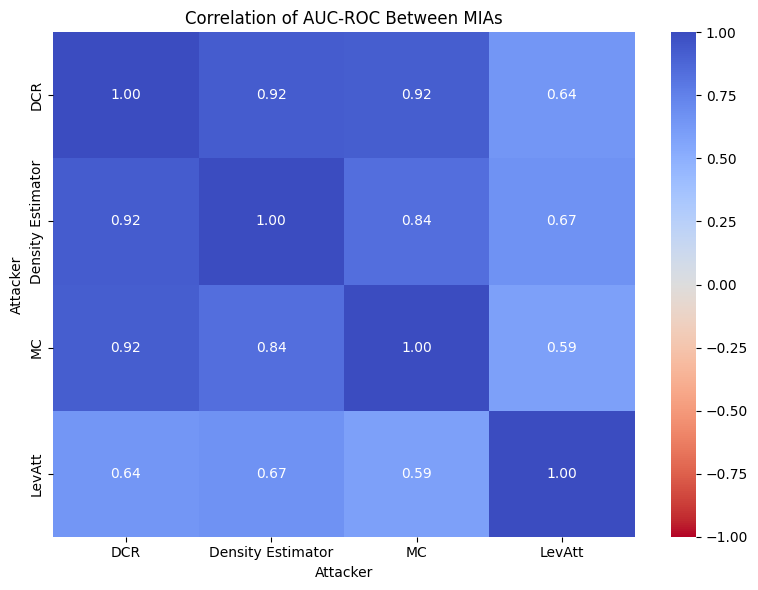

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the plot
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix, 
    annot=True,
    fmt=".2f",
    cmap='coolwarm_r',
    vmin=-1, vmax=1
)
plt.title("Correlation of AUC-ROC Between MIAs")
plt.xlabel("Attacker")
plt.ylabel("Attacker")
plt.tight_layout()
plt.show()



# Figure 2

Running levDCR attack...


Computing distances: 100%|██████████| 375/375 [00:00<00:00, 4606.20it/s]

levDCR evaluation: {'auc_roc': 1.0, 'tpr_at_fpr_0': 1.0, 'tpr_at_fpr_0.001': 1.0, 'tpr_at_fpr_0.01': 1.0, 'tpr_at_fpr_0.1': 1.0}
Running MC attack...
MC evaluation: {'auc_roc': 0.495603491902834, 'tpr_at_fpr_0': 0.0, 'tpr_at_fpr_0.001': 0.0, 'tpr_at_fpr_0.01': 0.0029375, 'tpr_at_fpr_0.1': 0.12998046875}
Running Density Estimate attack...
Density Estimate evaluation: {'auc_roc': 0.48870824898785425, 'tpr_at_fpr_0': 0.0078125, 'tpr_at_fpr_0.001': 0.0078125, 'tpr_at_fpr_0.01': 0.0390625, 'tpr_at_fpr_0.1': 0.1015625}
Running DCR attack...
DCR evaluation: {'auc_roc': 0.48975202429149794, 'tpr_at_fpr_0': 0.015625, 'tpr_at_fpr_0.001': 0.015625, 'tpr_at_fpr_0.01': 0.0234375, 'tpr_at_fpr_0.1': 0.1015625}


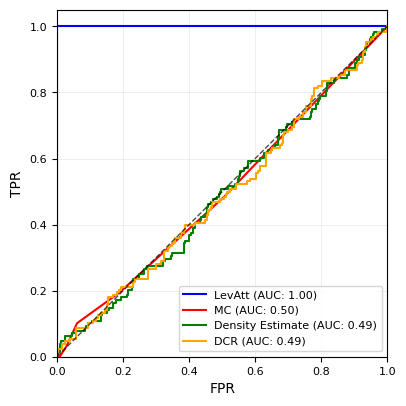


SUMMARY
LevAtt          | AUC: 1.000
MC              | AUC: 0.496
Density Estimate | AUC: 0.489
DCR             | AUC: 0.490


In [135]:
from synth_mia.attackers import (
    gen_lra, dcr, dpi, logan, dcr_diff, domias,
    mc, density_estimate, local_neighborhood, classifier, levDCR
)
from synth_mia.utils import tabular_preprocess
from rapidfuzz.distance import Levenshtein
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def row_to_str(row):
    return 'Value:'.join(
        str(round(float(val), 5)) if isinstance(val, (int, float, np.number)) else str(val)
        for val in row
    )

# Load data
mem_df = pd.read_csv('LTM_data/LTM_real_data/Moneyball/train/Moneyball--train--128-seed0.csv')
non_mem_df = pd.read_csv('LTM_data/LTM_real_data/Moneyball/test/Moneyball--test--999.csv')
synth_df = pd.read_csv('LTM_data/LTM_synthetic_data/LTM_tabpfn_synthetic_data/synth_Moneyball/Moneyball--train--128-seed0_tabpfn_default_0.csv')

# Prepare string representations for levDCR
df_array = mem_df.apply(row_to_str, axis=1).values.reshape(-1, 1)
non_mem_array = non_mem_df.apply(row_to_str, axis=1).values.reshape(-1, 1)
synth_array = synth_df.apply(row_to_str, axis=1).values.reshape(-1, 1)

# Prepare preprocessed data for other attackers
mem, non_mem, synth, transformer = tabular_preprocess(
    mem_df, non_mem_df, synth_df, fit_target='synth', categorical_encoding='ordinal'
)

# Dictionary to store results
results = {}

# Run levDCR attack
print("Running levDCR attack...")
att_levdcr = levDCR()
scores_levdcr, true_labels_levdcr = att_levdcr.attack(df_array, non_mem_array, synth_array)
results['LevAtt'] = (scores_levdcr, true_labels_levdcr)
print(f"levDCR evaluation: {att_levdcr.eval(true_labels_levdcr, scores_levdcr)}")

# Run other attacks
attackers = [
    ('MC', mc()),
    ('Density Estimate', density_estimate()),
    ('DCR', dcr())
]

for name, attacker in attackers:
    print(f"Running {name} attack...")
    scores, true_labels = attacker.attack(mem, non_mem, synth)
    results[name] = (scores, true_labels)
    print(f"{name} evaluation: {attacker.eval(true_labels, scores)}")

# Create compact ROC plot
fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

for i, (attack_name, (scores, true_labels)) in enumerate(results.items()):
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(true_labels, scores)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    ax.plot(fpr, tpr, color=colors[i % len(colors)], linewidth=1.5,
            label=f'{attack_name} (AUC: {roc_auc:.2f})')

# Plot random classifier line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.7)

# Compact styling
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('FPR', fontsize=10)
ax.set_ylabel('TPR', fontsize=10)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.tick_params(labelsize=8)

# Remove extra whitespace
plt.tight_layout(pad=0.5)
plt.show()

# Print summary statistics
print("\n" + "="*40)
print("SUMMARY")
print("="*40)
for attack_name, (scores, true_labels) in results.items():
    fpr, tpr, _ = roc_curve(true_labels, scores)
    roc_auc = auc(fpr, tpr)
    print(f"{attack_name:15s} | AUC: {roc_auc:.3f}")
print("="*40)

In [ ]:
# Filter first, then group
filtered_df = df[df['base'].str.contains('128|64|32', na=False)]
base_attacker_means = filtered_df[['auc_roc', 'tpr_at_fpr_0','tpr_at_fpr_0.1', 'continuous_columns','attacker','generator','base']].groupby(['base','generator','attacker']).mean()
base_attacker_means

auc_roc  \
base                        generator              attacker             
Moneyball--train--128-seed0 tabpfn                 DCR       0.489752   
                                                   levDCR    1.000000   
Moneyball--train--128-seed1 tabpfn                 DCR       0.519737   
                                                   levDCR    1.000000   
Moneyball--train--128-seed2 tabpfn                 DCR       0.510722   
...                                                               ...   
white-wine--train--64-seed2 gpt-4o-mini-2024-07-18 levDCR    0.500383   
                            llama                  DCR       0.502057   
                                                   levDCR    0.532167   
                            tabpfn                 DCR       0.536575   
                                                   levDCR    0.546301   

                                                             tpr_at_fpr_0  \
base                        generator              attacker                 
Moneyball--train--128-seed0 tabpfn                 DCR           0.015625   
                                                   levDCR        1.000000   
Moneyball--train--128-seed1 tabpfn                 DCR           0.000000   
                                                   levDCR        1.000000   
Moneyball--train--128-seed2 tabpfn                 DCR           0.000000   
...                                                                   ...   
white-wine--train--64-seed2 gpt-4o-mini-2024-07-18 levDCR        0.000000   
                            llama                  DCR           0.000000   
                                                   levDCR        0.000000   
                            tabpfn                 DCR           0.000000   
                                                   levDCR        0.000000   

                                                             tpr_at_fpr_0.1  \
base                        generator              attacker                   
Moneyball--train--128-seed0 tabpfn                 DCR             0.101562   
                                                   levDCR          1.000000   
Moneyball--train--128-seed1 tabpfn                 DCR             0.109375   
                                                   levDCR          1.000000   
Moneyball--train--128-seed2 tabpfn                 DCR             0.164062   
...                                                                     ...   
white-wine--train--64-seed2 gpt-4o-mini-2024-07-18 levDCR          0.100813   
                            llama                  DCR             0.109375   
                                                   levDCR          0.146756   
                            tabpfn                 DCR             0.140625   
                                                   levDCR          0.173018   

                                                             continuous_columns  
base                        generator              attacker                      
Moneyball--train--128-seed0 tabpfn                 DCR                      6.0  
                                                   levDCR                   6.0  
Moneyball--train--128-seed1 tabpfn                 DCR                      6.0  
                                                   levDCR                   6.0  
Moneyball--train--128-seed2 tabpfn                 DCR                      6.0  
...                                                                         ...  
white-wine--train--64-seed2 gpt-4o-mini-2024-07-18 levDCR                  11.0  
                            llama                  DCR                     11.0  
                                                   levDCR                  11.0  
                            tabpfn                 DCR                     11.0  
                                                   levDCR                  11.0  

[1692 rows x 4 

In [ ]:
from synth_mia.attackers import (
    gen_lra, dcr, dpi, logan, dcr_diff, domias,
    mc, density_estimate, local_neighborhood, classifier, levDCR
)
from rapidfuzz.distance import Levenshtein
from tqdm import tqdm
def row_to_str(row):
    return 'Value:'.join(
        str(round(float(val), 5)) if isinstance(val, (int, float, np.number)) else str(val)
        for val in row
    )
mem_df = pd.read_csv('LTM_data/LTM_real_data/Moneyball/train/Moneyball--train--128-seed0.csv')
non_mem_df =  pd.read_csv('LTM_data/LTM_real_data/Moneyball/test/Moneyball--test--999.csv')
synth_df = pd.read_csv('LTM_data/LTM_synthetic_data/LTM_tabpfn_synthetic_data/synth_Moneyball/Moneyball--train--128-seed0_tabpfn_default_0.csv')
df_array = mem_df.apply(row_to_str, axis=1).values.reshape(-1, 1)
non_mem_array = non_mem_df.apply(row_to_str, axis=1).values.reshape(-1, 1)
synth_array = synth_df.apply(row_to_str, axis=1).values.reshape(-1, 1)
att = levDCR()
scores, true_labels = att.attack(df_array, non_mem_array, synth_array)
att.eval(true_labels, scores)

Computing distances: 100%|██████████| 375/375 [00:00<00:00, 4779.61it/s]


{'auc_roc': 1.0,
 'tpr_at_fpr_0': 1.0,
 'tpr_at_fpr_0.001': 1.0,
 'tpr_at_fpr_0.01': 1.0,
 'tpr_at_fpr_0.1': 1.0}

In [ ]:
from synth_mia.utils import tabular_preprocess

mem, non_mem, synth, transformer = tabular_preprocess(
    mem_df, non_mem_df, synth_df, fit_target='synth', categorical_encoding='ordinal'
)

attackers = [mc(), density_estimate(), dcr()]
for attacker in attackers:
    scores, true_labels = attacker.attack(mem, non_mem, synth)
    print(attacker.eval(true_labels, scores))

{'auc_roc': 0.495603491902834, 'tpr_at_fpr_0': 0.0, 'tpr_at_fpr_0.001': 0.0, 'tpr_at_fpr_0.01': 0.0029375, 'tpr_at_fpr_0.1': 0.12998046875}
{'auc_roc': 0.48870824898785425, 'tpr_at_fpr_0': 0.0078125, 'tpr_at_fpr_0.001': 0.0078125, 'tpr_at_fpr_0.01': 0.0390625, 'tpr_at_fpr_0.1': 0.1015625}
{'auc_roc': 0.48975202429149794, 'tpr_at_fpr_0': 0.015625, 'tpr_at_fpr_0.001': 0.015625, 'tpr_at_fpr_0.01': 0.0234375, 'tpr_at_fpr_0.1': 0.1015625}


Running levDCR attack...


Computing distances: 100%|██████████| 375/375 [00:00<00:00, 4285.87it/s]

levDCR evaluation: {'auc_roc': 1.0, 'tpr_at_fpr_0': 1.0, 'tpr_at_fpr_0.001': 1.0, 'tpr_at_fpr_0.01': 1.0, 'tpr_at_fpr_0.1': 1.0}
Running MC attack...
MC evaluation: {'auc_roc': 0.495603491902834, 'tpr_at_fpr_0': 0.0, 'tpr_at_fpr_0.001': 0.0, 'tpr_at_fpr_0.01': 0.0029375, 'tpr_at_fpr_0.1': 0.12998046875}
Running Density Estimate attack...
Density Estimate evaluation: {'auc_roc': 0.48870824898785425, 'tpr_at_fpr_0': 0.0078125, 'tpr_at_fpr_0.001': 0.0078125, 'tpr_at_fpr_0.01': 0.0390625, 'tpr_at_fpr_0.1': 0.1015625}
Running DCR attack...
DCR evaluation: {'auc_roc': 0.48975202429149794, 'tpr_at_fpr_0': 0.015625, 'tpr_at_fpr_0.001': 0.015625, 'tpr_at_fpr_0.01': 0.0234375, 'tpr_at_fpr_0.1': 0.1015625}


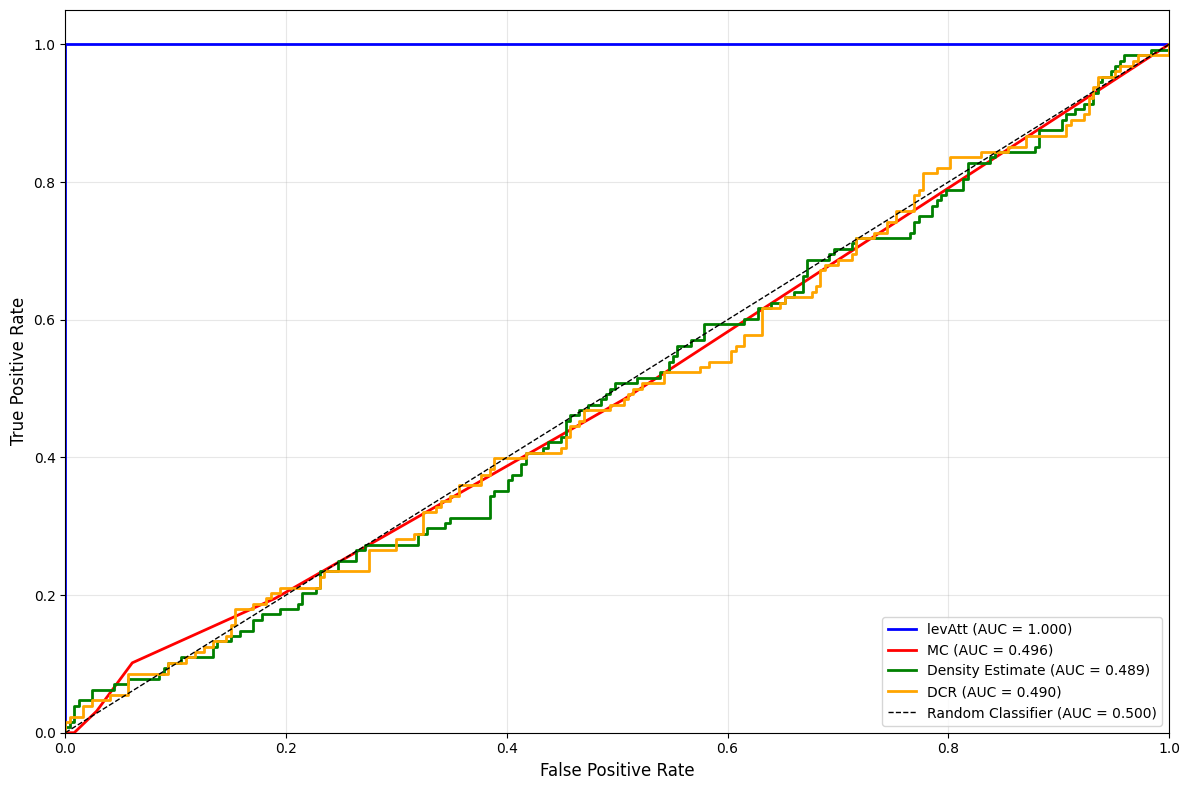


SUMMARY STATISTICS
levAtt               | AUC: 1.000
MC                   | AUC: 0.496
Density Estimate     | AUC: 0.489
DCR                  | AUC: 0.490


In [ ]:
from synth_mia.attackers import (
    gen_lra, dcr, dpi, logan, dcr_diff, domias,
    mc, density_estimate, local_neighborhood, classifier, levDCR
)
from synth_mia.utils import tabular_preprocess
from rapidfuzz.distance import Levenshtein
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def row_to_str(row):
    return 'Value:'.join(
        str(round(float(val), 5)) if isinstance(val, (int, float, np.number)) else str(val)
        for val in row
    )

# Load data
mem_df = pd.read_csv('LTM_data/LTM_real_data/Moneyball/train/Moneyball--train--128-seed0.csv')
non_mem_df = pd.read_csv('LTM_data/LTM_real_data/Moneyball/test/Moneyball--test--999.csv')
synth_df = pd.read_csv('LTM_data/LTM_synthetic_data/LTM_tabpfn_synthetic_data/synth_Moneyball/Moneyball--train--128-seed0_tabpfn_default_0.csv')

# Prepare string representations for levDCR
df_array = mem_df.apply(row_to_str, axis=1).values.reshape(-1, 1)
non_mem_array = non_mem_df.apply(row_to_str, axis=1).values.reshape(-1, 1)
synth_array = synth_df.apply(row_to_str, axis=1).values.reshape(-1, 1)

# Prepare preprocessed data for other attackers
mem, non_mem, synth, transformer = tabular_preprocess(
    mem_df, non_mem_df, synth_df, fit_target='synth', categorical_encoding='ordinal'
)

# Dictionary to store results
results = {}

# Run levDCR attack
print("Running levDCR attack...")
att_levdcr = levDCR()
scores_levdcr, true_labels_levdcr = att_levdcr.attack(df_array, non_mem_array, synth_array)
results['levAtt'] = (scores_levdcr, true_labels_levdcr)
print(f"levDCR evaluation: {att_levdcr.eval(true_labels_levdcr, scores_levdcr)}")

# Run other attacks
attackers = [
    ('MC', mc()),
    ('Density Estimate', density_estimate()),
    ('DCR', dcr())
]

for name, attacker in attackers:
    print(f"Running {name} attack...")
    scores, true_labels = attacker.attack(mem, non_mem, synth)
    results[name] = (scores, true_labels)
    print(f"{name} evaluation: {attacker.eval(true_labels, scores)}")

# Plot ROC curves
plt.figure(figsize=(12, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

for i, (attack_name, (scores, true_labels)) in enumerate(results.items()):
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(true_labels, scores)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, color=colors[i % len(colors)], linewidth=2,
             label=f'{attack_name} (AUC = {roc_auc:.3f})')

# Plot random classifier line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')

# Customize plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)

# Add some styling
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
for attack_name, (scores, true_labels) in results.items():
    fpr, tpr, _ = roc_curve(true_labels, scores)
    roc_auc = auc(fpr, tpr)
    print(f"{attack_name:20s} | AUC: {roc_auc:.3f}")
print("="*60)

Running levDCR attack...


Computing distances: 100%|██████████| 375/375 [00:00<00:00, 4700.53it/s]

levDCR evaluation: {'auc_roc': 1.0, 'tpr_at_fpr_0': 1.0, 'tpr_at_fpr_0.001': 1.0, 'tpr_at_fpr_0.01': 1.0, 'tpr_at_fpr_0.1': 1.0}
Running MC attack...
MC evaluation: {'auc_roc': 0.495603491902834, 'tpr_at_fpr_0': 0.0, 'tpr_at_fpr_0.001': 0.0, 'tpr_at_fpr_0.01': 0.0029375, 'tpr_at_fpr_0.1': 0.12998046875}
Running Density Estimate attack...
Density Estimate evaluation: {'auc_roc': 0.48870824898785425, 'tpr_at_fpr_0': 0.0078125, 'tpr_at_fpr_0.001': 0.0078125, 'tpr_at_fpr_0.01': 0.0390625, 'tpr_at_fpr_0.1': 0.1015625}
Running DCR attack...
DCR evaluation: {'auc_roc': 0.48975202429149794, 'tpr_at_fpr_0': 0.015625, 'tpr_at_fpr_0.001': 0.015625, 'tpr_at_fpr_0.01': 0.0234375, 'tpr_at_fpr_0.1': 0.1015625}


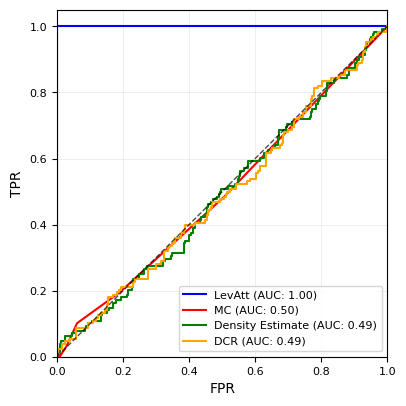


SUMMARY
LevAtt          | AUC: 1.000
MC              | AUC: 0.496
Density Estimate | AUC: 0.489
DCR             | AUC: 0.490


In [ ]:
from synth_mia.attackers import (
    gen_lra, dcr, dpi, logan, dcr_diff, domias,
    mc, density_estimate, local_neighborhood, classifier, levDCR
)
from synth_mia.utils import tabular_preprocess
from rapidfuzz.distance import Levenshtein
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def row_to_str(row):
    return 'Value:'.join(
        str(round(float(val), 5)) if isinstance(val, (int, float, np.number)) else str(val)
        for val in row
    )

# Load data
mem_df = pd.read_csv('LTM_data/LTM_real_data/Moneyball/train/Moneyball--train--128-seed0.csv')
non_mem_df = pd.read_csv('LTM_data/LTM_real_data/Moneyball/test/Moneyball--test--999.csv')
synth_df = pd.read_csv('LTM_data/LTM_synthetic_data/LTM_tabpfn_synthetic_data/synth_Moneyball/Moneyball--train--128-seed0_tabpfn_default_0.csv')

# Prepare string representations for levDCR
df_array = mem_df.apply(row_to_str, axis=1).values.reshape(-1, 1)
non_mem_array = non_mem_df.apply(row_to_str, axis=1).values.reshape(-1, 1)
synth_array = synth_df.apply(row_to_str, axis=1).values.reshape(-1, 1)

# Prepare preprocessed data for other attackers
mem, non_mem, synth, transformer = tabular_preprocess(
    mem_df, non_mem_df, synth_df, fit_target='synth', categorical_encoding='ordinal'
)

# Dictionary to store results
results = {}

# Run levDCR attack
print("Running levDCR attack...")
att_levdcr = levDCR()
scores_levdcr, true_labels_levdcr = att_levdcr.attack(df_array, non_mem_array, synth_array)
results['LevAtt'] = (scores_levdcr, true_labels_levdcr)
print(f"levDCR evaluation: {att_levdcr.eval(true_labels_levdcr, scores_levdcr)}")

# Run other attacks
attackers = [
    ('MC', mc()),
    ('Density Estimate', density_estimate()),
    ('DCR', dcr())
]

for name, attacker in attackers:
    print(f"Running {name} attack...")
    scores, true_labels = attacker.attack(mem, non_mem, synth)
    results[name] = (scores, true_labels)
    print(f"{name} evaluation: {attacker.eval(true_labels, scores)}")

# Create compact ROC plot
fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

for i, (attack_name, (scores, true_labels)) in enumerate(results.items()):
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(true_labels, scores)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    ax.plot(fpr, tpr, color=colors[i % len(colors)], linewidth=1.5,
            label=f'{attack_name} (AUC: {roc_auc:.2f})')

# Plot random classifier line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.7)

# Compact styling
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('FPR', fontsize=10)
ax.set_ylabel('TPR', fontsize=10)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.tick_params(labelsize=8)

# Remove extra whitespace
plt.tight_layout(pad=0.5)
plt.show()

# Print summary statistics
print("\n" + "="*40)
print("SUMMARY")
print("="*40)
for attack_name, (scores, true_labels) in results.items():
    fpr, tpr, _ = roc_curve(true_labels, scores)
    roc_auc = auc(fpr, tpr)
    print(f"{attack_name:15s} | AUC: {roc_auc:.3f}")
print("="*40)

## Figure 4

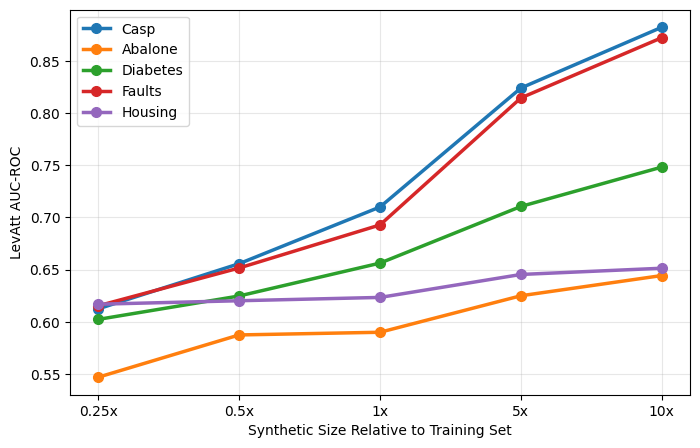

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("LLM_LEVATTACK/attack/rtf/rtf_n_mia_evaluation_summary.csv")

# Filter out datasets that start with 'exp'
df_filtered = df[~df['experiment'].str.startswith('exp')]
df_filtered = df_filtered[~df_filtered['experiment'].str.startswith('Ch')]

# Pivot data so sizes are x-axis and AUCs are y-axis per dataset
pivot_df = df_filtered.pivot(index='synth_file', columns='experiment', values='lev_auc_roc')

# Define custom order for sizes
size_order = ['025x.csv', '05x.csv', '1x.csv', '5x.csv', '10x.csv']

# Filter to only include sizes that exist in the data
size_order = [s for s in size_order if s in pivot_df.index]

# Reorder the dataframe
pivot_df = pivot_df.loc[size_order]

# Clean x-axis labels: remove .csv and rename 025x -> 0.25x, 05x -> 0.5x
pivot_df.index = pivot_df.index.str.replace('.csv', '')
pivot_df.index = pivot_df.index.str.replace('025x', '0.25x')
pivot_df.index = pivot_df.index.str.replace('05x', '0.5x')

# Define diverse colors and markers
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plot
plt.figure(figsize=(8,5))
for i, dataset in enumerate(pivot_df.columns):
    color = colors[i % len(colors)]
    plt.plot(pivot_df.index, pivot_df[dataset], marker='o', linewidth=2.5,
             markersize=7, label=dataset.capitalize(), color=color)

plt.xlabel("Synthetic Size Relative to Training Set")
plt.ylabel("LevAtt AUC-ROC")
plt.grid(alpha=0.3)  # subtle grid
plt.legend()
plt.show()

## Figure 9

/tmp/ipykernel_2253/1376142623.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("epsilon")[list(metrics.keys())].agg(["mean", "std"])


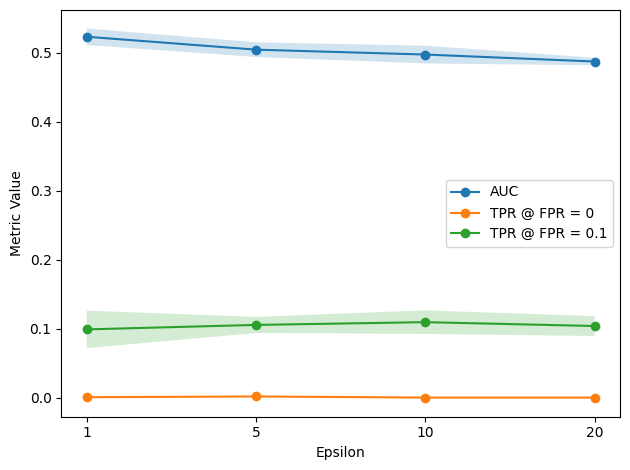

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("LLM_LEVATTACK/attack/dp2stage_ep_ablation/dp_ablation_mia_evaluation_summary.csv")


# Extract epsilon group (1x_1 -> 1, etc.)
df["epsilon"] = df["synth_file"].str.extract(r"1x_(\d+)").astype(int)

# Ensure correct order
epsilon_order = [1, 5, 10, 20]
df["epsilon"] = pd.Categorical(df["epsilon"], categories=epsilon_order, ordered=True)

# Metrics + readable labels
metrics = {
    "lev_auc_roc": "AUC",
    "lev_tpr_at_fpr_0": "TPR @ FPR = 0",
    "lev_tpr_at_fpr_0.1": "TPR @ FPR = 0.1"
}

# Compute mean and std
summary = df.groupby("epsilon")[list(metrics.keys())].agg(["mean", "std"])

x = range(len(epsilon_order))

plt.figure()

for metric, label in metrics.items():
    mean = summary[(metric, "mean")].values
    std = summary[(metric, "std")].values
    
    line, = plt.plot(x, mean, marker='o', label=label)
    
    plt.fill_between(
        x,
        mean - std,
        mean + std,
        alpha=0.2
    )

plt.xticks(x, epsilon_order)
plt.xlabel("Epsilon")
plt.ylabel("Metric Value")
# plt.title("Lev Attack Metrics (Mean ± Std)")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
pivot_df

experiment,diabetes
synth_file,


## Figure 5

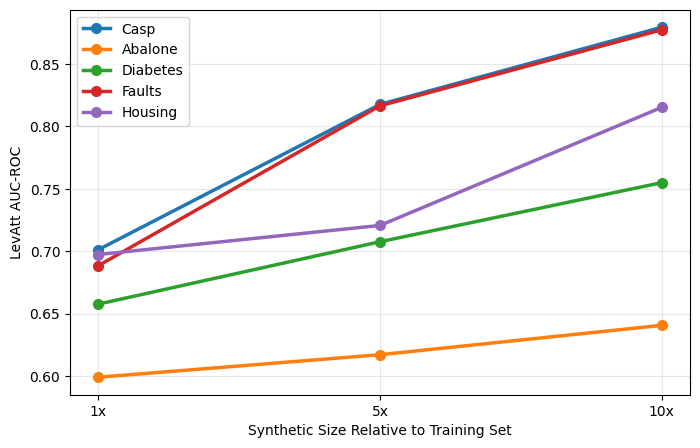

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("Untitled spreadsheet - Sheet4.csv")

# Filter out datasets that start with 'exp'
df_filtered = df[~df['Dataset'].str.startswith('exp')]
df_filtered = df_filtered[~df_filtered['Dataset'].str.startswith('Ch')]

# Pivot data so sizes are x-axis and AUCs are y-axis per dataset
# Assuming 'size' column has values like '5x', '10x', etc.
pivot_df = df_filtered.pivot(index='size', columns='Dataset', values='AUC-ROC')

# Sort x-axis by size if needed
size_order = sorted(pivot_df.index, key=lambda x: int(x.replace('x.csv','')))
pivot_df = pivot_df.loc[size_order]

# Clean x-axis labels by removing .csv extension
pivot_df.index = pivot_df.index.str.replace('.csv', '')

# Define diverse colors and markers
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plot
plt.figure(figsize=(8,5))
for i, dataset in enumerate(pivot_df.columns):
    color = colors[i % len(colors)]
    plt.plot(pivot_df.index, pivot_df[dataset], marker='o', linewidth=2.5,
             markersize=7, label=dataset.capitalize(), color=color)

plt.xlabel("Synthetic Size Relative to Training Set")
plt.ylabel("LevAtt AUC-ROC")
plt.grid(alpha=0.3)  # subtle grid
plt.legend()
plt.show()

## Table 2

In [4]:
sft_lev = pd.read_csv('LLM_LEVATTACK/attack/sft_data/mia_evaluation_summary.csv')
sft_fid = pd.read_csv('LLM_LEVATTACK/attack/sft_data/fidelity_utility_summary.csv')
sft_fid['synth_file']= sft_fid['file']
# Performing the left join on the three specified keys
sft_combined = pd.merge(
    sft_lev, 
    sft_fid, 
    on=['experiment', 'model_type', 'synth_file'], 
    how='left'
)

# 1. Define your specific metric lists
attack_metrics = [
    'lev_auc_roc', 'lev_tpr_at_fpr_0', 'lev_tpr_at_fpr_0.1'
]
fidelity_metrics = [
    'mmd', 'wass', 'auc_roc', 'f1_score', 'rmse'
]
all_metrics = attack_metrics + fidelity_metrics

# 2. Perform the grouping and calculate mean and std
sft_summary = sft_combined.groupby(['model_type', 'experiment'])[all_metrics].agg(['mean', 'std'])

# 3. Flatten columns for easier export: e.g., 'f1_score_mean', 'f1_score_std'
sft_summary.columns = [f"{col[0]}_{col[1]}" for col in sft_summary.columns]
sft_summary = sft_summary.reset_index()

# 4. View results
(sft_summary.round(2))

,model_type,experiment,lev_auc_roc_mean,lev_auc_roc_std,lev_tpr_at_fpr_0_mean,lev_tpr_at_fpr_0_std,lev_tpr_at_fpr_0.1_mean,lev_tpr_at_fpr_0.1_std,mmd_mean,mmd_std,wass_mean,wass_std,auc_roc_mean,auc_roc_std,f1_score_mean,f1_score_std,rmse_mean,rmse_std
0,ctgan,CASP,0.49,0.01,0.00,0.00,0.10,0.01,0.01,0.00,0.05,0.01,NaN,NaN,NaN,NaN,2.28,0.20
1,ctgan,abalone,0.50,0.00,0.00,0.00,0.06,0.00,0.02,0.00,0.03,0.00,NaN,NaN,NaN,NaN,2.71,0.09
2,ctgan,diabetes,0.48,0.00,0.00,0.00,0.09,0.00,0.01,0.00,0.17,0.01,0.74,0.05,0.67,0.06,NaN,NaN
3,ctgan,faults,0.49,0.01,0.00,0.00,0.09,0.02,0.01,0.00,0.87,0.18,0.87,0.02,0.79,0.03,NaN,NaN
4,ctgan,housing,0.50,0.01,0.00,0.00,0.09,0.01,0.01,0.00,0.08,0.01,0.93,0.00,0.78,0.02,NaN,NaN
5,dp2stage,CASP,0.48,0.00,0.00,0.00,0.09,0.01,0.01,0.00,0.29,0.05,NaN,NaN,NaN,NaN,6.22,0.30
6,dp2stage,abalone,0.48,0.00,0.00,0.00,0.08,0.01,0.14,0.01,1.72,0.06,0.49,0.01,0.08,0.01,NaN,NaN
7,dp2stage,diabetes,0.50,0.01,0.00,0.00,0.11,0.02,0.01,0.00,0.91,0.01,0.50,0.00,0.50,0.00,NaN,NaN
8,dp2stage,housing,0.53,0.00,0.00,0.00,0.10,0.01,0.01,0.00,1.41,0.10,0.50,0.00,0.26,0.00,NaN,NaN
9,gpt2,CASP,0.51,0.01,0.00,0.00,0.10,0.00,0.01,0.00,0.03,0.00,NaN,NaN,NaN,NaN,1.97,0.02


In [7]:
# 1. Define your mapping
model_name_mapping = {
    'rtf': 'RealTabFormer',
    'rtf_llama_1b': 'LLaMA 3.2-1B',
    'rtf_llama_32_3b': 'LLaMA 3.2-3B',
    'gpt2': 'GPT2',
    'great': 'GReaT',
    'qwen3b': 'Qwen 2.5-3B',
    'mistral': 'Mistral-7B',
    'tvae': 'TVAE',
    'ctgan': 'CT-GAN',
    'dp2stage': 'DP2Stage'
}
sft_combined['model_name'] = sft_combined['model_type'].map(model_name_mapping)

# 1. & 2. Group and aggregate
sft_summary = sft_combined.groupby(['model_name', 'experiment'])[metrics].agg(['mean', 'std'])

# Fix the MultiIndex columns by flattening them
# This turns ('lev_auc_roc', 'mean') into 'lev_auc_roc_mean'
sft_summary.columns = [f"{col[0]}_{col[1]}" for col in sft_summary.columns]

# Move 'model_name' and 'experiment' from Index back to Columns
formatted_df = sft_summary.reset_index()

# 3. & 4. Format the strings
for metric in metrics:
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"
    
    # Use f-strings for cleaner formatting to 2 decimal places
    formatted_df[metric] = (
        formatted_df[mean_col].map('{:.2f}'.format) + 
        " ± " + 
        formatted_df[std_col].fillna(0).map('{:.2f}'.format)
    )

# 5. Sorting
model_order = [
    'RealTabFormer', 'LLaMA 3.2-1B', 'LLaMA 3.2-3B', 'GPT2', 
    'GREAT', 'Qwen 2.5-3B', 'Mistral-7B', 'TVAE', 'CT-GAN', 'DP2Stage'
]
formatted_df['model_name'] = pd.Categorical(formatted_df['model_name'], categories=model_order, ordered=True)
formatted_df = formatted_df.sort_values(['model_name', 'experiment'])

# Final selection of columns to display
final_table = formatted_df[['model_name', 'experiment'] + metrics]

In [9]:
import pandas as pd

metric_map = {
    'lev_auc_roc': 'Lev-AUC',
    'lev_tpr_at_fpr_0.1': 'TPR@FPR=0.1',
}

# Define the specific order for experiments
experiment_order = ['housing', 'diabetes', 'CASP', 'faults', 'abalone']

# 2. Round and Format
formatted_rows = []
sft_summary = sft_summary.reset_index()
for _, row in sft_summary.iterrows():
    raw_model = row['model_name']
    model = model_name_mapping.get(raw_model, raw_model) 
    exp = row['experiment']
    
    for raw_col, clean_name in metric_map.items():
        mean_val = row.get(f"{raw_col}_mean")
        std_val = row.get(f"{raw_col}_std")
        
        if pd.isna(mean_val):
            cell_value = "---"
        else:
            # Handle NaN std as 0.0
            std_val = 0.0 if pd.isna(std_val) else std_val
            cell_value = f"${mean_val:.2f} \\pm {std_val:.2f}$"
            
        formatted_rows.append({
            'Model': model,
            'Metric': clean_name,
            'Experiment': exp,
            'Value': cell_value
        })

# 3. Create DataFrame
df_formatted = pd.DataFrame(formatted_rows)

# 4. Set Categorical Orders (Crucial for the Pivot order)
model_order = list(model_name_mapping.values())
df_formatted['Model'] = pd.Categorical(df_formatted['Model'], categories=model_order, ordered=True)
df_formatted['Experiment'] = pd.Categorical(df_formatted['Experiment'], categories=experiment_order, ordered=True)

# Sort so the pivot uses the categorical order
df_formatted = df_formatted.sort_values(['Model', 'Experiment'])

# 5. Pivot
df_pivot = df_formatted.pivot(index=['Model', 'Metric'], 
                               columns='Experiment', 
                               values='Value')

# Re-index columns just to be absolutely certain of the order
df_pivot = df_pivot[experiment_order]

# 6. Generate the LaTeX Table String
latex_table = df_pivot.to_latex(
    multirow=True, 
    escape=False, 
    column_format='ll' + 'c' * len(df_pivot.columns),
    caption="Model performance across multiple experiments",
    label="tab:model_results"
)

print(latex_table)

\begin{table}
\caption{Model performance across multiple experiments}
\label{tab:model_results}
\begin{tabular}{llccccc}
\toprule
 & Experiment & housing & diabetes & CASP & faults & abalone \\
Model & Metric &  &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{RealTabFormer} & Lev-AUC & $0.62 \pm 0.01$ & $0.67 \pm 0.01$ & $0.70 \pm 0.01$ & $0.69 \pm 0.00$ & $0.59 \pm 0.00$ \\
 & TPR@FPR=0.1 & --- & --- & --- & --- & --- \\
\cline{1-7}
\multirow[t]{2}{*}{LLaMA 3.2-1B} & Lev-AUC & $0.58 \pm 0.00$ & $0.57 \pm 0.00$ & $0.51 \pm 0.01$ & $0.56 \pm 0.01$ & $0.52 \pm 0.00$ \\
 & TPR@FPR=0.1 & --- & --- & --- & --- & --- \\
\cline{1-7}
\multirow[t]{2}{*}{LLaMA 3.2-3B} & Lev-AUC & $0.59 \pm 0.01$ & $0.57 \pm 0.01$ & $0.50 \pm 0.00$ & $0.55 \pm 0.01$ & $0.57 \pm 0.00$ \\
 & TPR@FPR=0.1 & --- & --- & --- & --- & --- \\
\cline{1-7}
\multirow[t]{2}{*}{GPT2} & Lev-AUC & $0.59 \pm 0.00$ & $0.51 \pm 0.00$ & $0.51 \pm 0.01$ & $0.52 \pm 0.00$ & NaN \\
 & TPR@FPR=0.1 & --- & --- & --- & --- & NaN \\
\cline{1-7}

## Table 3

In [5]:

# 2. Perform the grouping and calculate mean and std
sft_summary = sft_combined.groupby(['model_type'])[all_metrics].agg(['mean', 'std'])

# 3. Flatten columns for easier export: e.g., 'f1_score_mean', 'f1_score_std'
sft_summary.columns = [f"{col[0]}_{col[1]}" for col in sft_summary.columns]
sft_summary = sft_summary.reset_index()

# 4. View results
(sft_summary.round(2))
summary_rounded = sft_summary.round(2).copy()

# 2. Define the metrics you want to format
metrics = [
    'lev_auc_roc',
    'mmd', 'wass', 'auc_roc'
]

# 3. Create a new DataFrame for the formatted strings
formatted_df = summary_rounded[['model_type']].copy()

for metric in metrics:
    # Combine mean and std into "mean ± std" format
    formatted_df[metric] = (
        summary_rounded[f"{metric}_mean"].astype(str) + 
        " ± " + 
        summary_rounded[f"{metric}_std"].astype(str)
    )

# Display the final table
(formatted_df)

,model_type,lev_auc_roc,mmd,wass,auc_roc
0,ctgan,0.49 ± 0.01,0.01 ± 0.0,0.24 ± 0.34,0.85 ± 0.09
1,dp2stage,0.5 ± 0.02,0.04 ± 0.06,1.08 ± 0.57,0.5 ± 0.01
2,gpt2,0.53 ± 0.04,0.01 ± 0.0,0.45 ± 0.65,0.75 ± 0.19
3,great,0.53 ± 0.03,0.01 ± 0.0,7.0 ± 23.44,0.83 ± 0.26
4,mistral,0.53 ± 0.03,0.02 ± 0.01,16.4 ± 33.6,0.64 ± 0.16
5,qwen3b,0.56 ± 0.05,0.01 ± 0.0,0.2 ± 0.27,0.88 ± 0.16
6,rtf,0.65 ± 0.04,0.01 ± 0.0,0.13 ± 0.17,0.92 ± 0.11
7,rtf_llama_1b,0.54 ± 0.03,0.03 ± 0.03,0.31 ± 0.34,0.89 ± 0.14
8,rtf_llama_32_3b,0.56 ± 0.03,0.02 ± 0.02,0.33 ± 0.48,0.83 ± 0.12
9,tvae,0.5 ± 0.01,0.01 ± 0.0,0.19 ± 0.26,0.88 ± 0.13
